# Part 1: Standard Mean-Variance Portfolio Optimization

In [23]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as sco
import warnings
warnings.filterwarnings('ignore')
import pandas_datareader.data as web
import statsmodels.api as sm
from datetime import datetime
import time

Configuration

In [11]:
tickers = ['TSLA', 'WMT', 'BAC', 'GS', 'LLY', 'MRK', 'GOOG', 'META', 'AAPL', 'XOM']
# added one day to end dates to ensure yfinance fetches the complete last day
train_start = '2023-09-01'
train_end = '2025-10-01' 
test_start = '2025-10-01'
test_end = '2026-01-01'
risk_free_rate = 0.04 # Annualized risk-free rate assumption (4%)
trading_days = 252

Data Aquisition

In [12]:
data_train = yf.download(tickers, start=train_start, end=train_end, auto_adjust=True)['Close']
data_test  = yf.download(tickers, start=test_start, end=test_end, auto_adjust=True)['Close']

[*********************100%***********************]  10 of 10 completed
[*********************100%***********************]  10 of 10 completed


In [13]:
print(data_train.shape)    
print(len(tickers))        

(521, 10)
10


In [14]:
# Calculate daily simple returns
returns_train = data_train.pct_change().dropna()
returns_test  = data_test.pct_change().dropna()

# Calculate annualized mean returns and covariance matrix
mean_returns = returns_train.mean() * trading_days
cov_matrix   = returns_train.cov() * trading_days

Helper Functions

In [15]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.04):
    returns = np.sum(mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (returns - risk_free_rate) / std_dev
    return returns, std_dev, sharpe_ratio

def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0.04):
    _, _, sharpe = portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)
    return -sharpe

def minimize_volatility(weights, mean_returns, cov_matrix):
    _, std_dev, _ = portfolio_performance(weights, mean_returns, cov_matrix)
    return std_dev

## STEP 1: Standard Optimal Mean-Variance Portfolio (Sum=1, No Short)

In [16]:
num_assets = len(tickers)
args = (mean_returns, cov_matrix, risk_free_rate)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds_step1 = tuple((0.0, 1.0) for asset in range(num_assets)) # No short selling

result_step1 = sco.minimize(negative_sharpe, num_assets*[1./num_assets,], args=args,
                            method='SLSQP', bounds=bounds_step1, constraints=constraints)

weights_step1 = result_step1.x
ret_1, vol_1, sharpe_1 = portfolio_performance(weights_step1, mean_returns, cov_matrix)

## STEP 2: Constrained Optimal Mean-Variance Portfolio (Max Weight = 0.18)

In [17]:
bounds_step2 = tuple((0.0, 0.18) for asset in range(num_assets)) # Cap at 18%

result_step2 = sco.minimize(negative_sharpe, num_assets*[1./num_assets,], args=args,
                            method='SLSQP', bounds=bounds_step2, constraints=constraints)

weights_step2 = result_step2.x
ret_2, vol_2, sharpe_2 = portfolio_performance(weights_step2, mean_returns, cov_matrix)

print("\n--- IN-SAMPLE ALLOCATIONS (Train Period) ---")
print("Step 1 Optimal Weights (No Max Weight):")
for ticker, weight in zip(tickers, weights_step1):
    print(f"{ticker}: {weight:.4f}")
print(f"Expected Return: {ret_1:.4f}, Volatility: {vol_1:.4f}, Sharpe: {sharpe_1:.4f}")

print("\nStep 2 Constrained Weights (Max 18%):")
for ticker, weight in zip(tickers, weights_step2):
    print(f"{ticker}: {weight:.4f}")
print(f"Expected Return: {ret_2:.4f}, Volatility: {vol_2:.4f}, Sharpe: {sharpe_2:.4f}")


--- IN-SAMPLE ALLOCATIONS (Train Period) ---
Step 1 Optimal Weights (No Max Weight):
TSLA: 0.0000
WMT: 0.0000
BAC: 0.0523
GS: 0.3550
LLY: 0.0000
MRK: 0.1450
GOOG: 0.0000
META: 0.0000
AAPL: 0.4477
XOM: 0.0000
Expected Return: 0.4218, Volatility: 0.1908, Sharpe: 2.0007

Step 2 Constrained Weights (Max 18%):
TSLA: 0.0000
WMT: 0.1800
BAC: 0.1800
GS: 0.1800
LLY: 0.0883
MRK: 0.1800
GOOG: 0.0000
META: 0.0000
AAPL: 0.1800
XOM: 0.0117
Expected Return: 0.3826, Volatility: 0.1896, Sharpe: 1.8064


## STEP 3: Efficient Frontiers

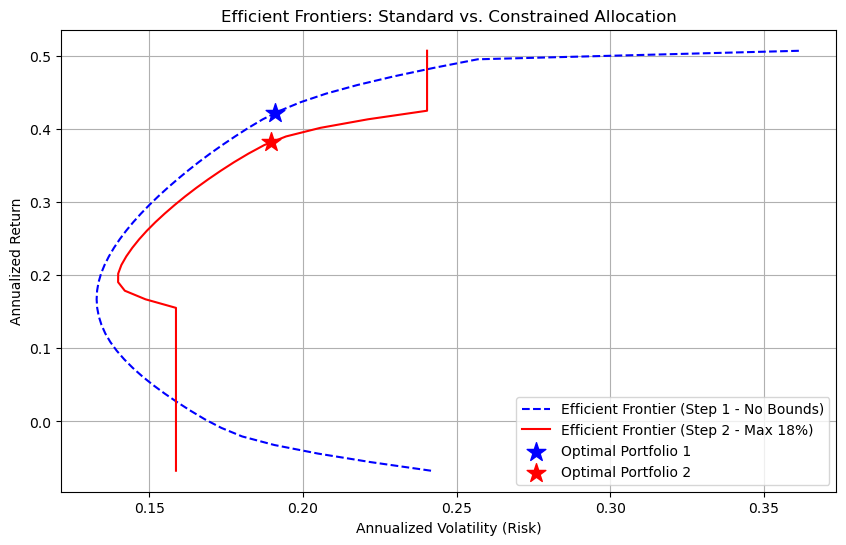

In [18]:
def get_efficient_frontier(mean_returns, cov_matrix, bounds):
    target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)
    target_volatilities = []
    
    for target in target_returns:
        cons = ({'type': 'eq', 'fun': lambda x: portfolio_performance(x, mean_returns, cov_matrix)[0] - target},
                {'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
        result = sco.minimize(minimize_volatility, num_assets*[1./num_assets,], args=(mean_returns, cov_matrix),
                              method='SLSQP', bounds=bounds, constraints=cons)
        target_volatilities.append(result.fun)
    return target_volatilities, target_returns

vol_ef1, ret_ef1 = get_efficient_frontier(mean_returns, cov_matrix, bounds_step1)
vol_ef2, ret_ef2 = get_efficient_frontier(mean_returns, cov_matrix, bounds_step2)

plt.figure(figsize=(10, 6))
plt.plot(vol_ef1, ret_ef1, 'b--', label='Efficient Frontier (Step 1 - No Bounds)')
plt.plot(vol_ef2, ret_ef2, 'r-', label='Efficient Frontier (Step 2 - Max 18%)')
plt.scatter(vol_1, ret_1, marker='*', color='blue', s=200, label='Optimal Portfolio 1')
plt.scatter(vol_2, ret_2, marker='*', color='red', s=200, label='Optimal Portfolio 2')
plt.title('Efficient Frontiers: Standard vs. Constrained Allocation')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend()
plt.grid(True)
plt.show()

## STEP 4: Out-of-Sample Performance Evaluation


--- OUT-OF-SAMPLE PERFORMANCE (Oct 1, 2025 - Dec 31, 2025) ---
Step 1 Portfolio (Unconstrained):
Cumulative Return: 9.3033%
Annualized Sharpe Ratio: 2.2493
Max Drawdown: -4.6895%

Step 2 Portfolio (Max 18%):
Cumulative Return: 12.0134%
Annualized Sharpe Ratio: 3.1054
Max Drawdown: -2.9200%


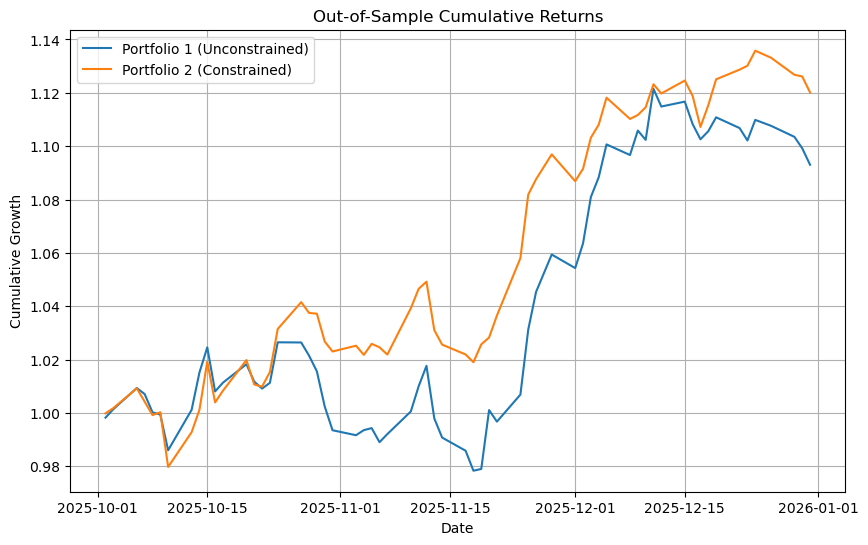

In [19]:
def calculate_drawdown(cum_returns):
    rolling_max = cum_returns.cummax()
    drawdown = cum_returns / rolling_max - 1.0
    return drawdown.min()

# Calculate daily portfolio returns for the test period
port_ret_test_1 = returns_test.dot(weights_step1)
port_ret_test_2 = returns_test.dot(weights_step2)

# Cumulative Returns
cum_ret_1 = (1 + port_ret_test_1).cumprod()
cum_ret_2 = (1 + port_ret_test_2).cumprod()

total_cum_ret_1 = cum_ret_1.iloc[-1] - 1
total_cum_ret_2 = cum_ret_2.iloc[-1] - 1

# Out-of-sample Sharpe Ratio (Annualized)
sharpe_test_1 = (port_ret_test_1.mean() * trading_days - risk_free_rate) / (port_ret_test_1.std() * np.sqrt(trading_days))
sharpe_test_2 = (port_ret_test_2.mean() * trading_days - risk_free_rate) / (port_ret_test_2.std() * np.sqrt(trading_days))

# Max Drawdown
mdd_1 = calculate_drawdown(cum_ret_1)
mdd_2 = calculate_drawdown(cum_ret_2)

print("\n--- OUT-OF-SAMPLE PERFORMANCE (Oct 1, 2025 - Dec 31, 2025) ---")
print("Step 1 Portfolio (Unconstrained):")
print(f"Cumulative Return: {total_cum_ret_1:.4%}")
print(f"Annualized Sharpe Ratio: {sharpe_test_1:.4f}")
print(f"Max Drawdown: {mdd_1:.4%}")

print("\nStep 2 Portfolio (Max 18%):")
print(f"Cumulative Return: {total_cum_ret_2:.4%}")
print(f"Annualized Sharpe Ratio: {sharpe_test_2:.4f}")
print(f"Max Drawdown: {mdd_2:.4%}")

# Plot Cumulative Returns Out-of-Sample
plt.figure(figsize=(10, 6))
plt.plot(cum_ret_1.index, cum_ret_1, label='Portfolio 1 (Unconstrained)')
plt.plot(cum_ret_2.index, cum_ret_2, label='Portfolio 2 (Constrained)')
plt.title('Out-of-Sample Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth')
plt.legend()
plt.grid(True)
plt.show()

# Part 2: Factor Exposure and Style Analysis

In [21]:
# Fetch daily Fama-French 5 factors
ff_dict = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench', start=train_start, end=test_end)
ff_data = ff_dict[0] # The actual dataframe

# Convert index to timezone-naive datetime to match yfinance data
ff_data.index = pd.to_datetime(ff_data.index)
if ff_data.index.tz is not None:
    ff_data.index = ff_data.index.tz_localize(None)

returns_train.index = pd.to_datetime(returns_train.index)
if returns_train.index.tz is not None:
    returns_train.index = returns_train.index.tz_localize(None)

returns_test.index = pd.to_datetime(returns_test.index)
if returns_test.index.tz is not None:
    returns_test.index = returns_test.index.tz_localize(None)

# Calculate Daily Portfolio 2 Returns for Train and Test sets
port_ret_train_2 = returns_train.dot(weights_step2) * 100 # Convert to percentage to match FF data scale
port_ret_test_2 = returns_test.dot(weights_step2) * 100

# Align training data
train_data = pd.concat([port_ret_train_2.rename('Port_Return'), ff_data], axis=1).dropna()
# Align testing data
test_data = pd.concat([port_ret_test_2.rename('Port_Return'), ff_data], axis=1).dropna()

print("\n--- FACTOR CORRELATION MATRIX (In-Sample) ---")
factors = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
print(train_data[factors].corr().round(4))

# Prepare variables for regression
# Dependent variable: Portfolio Return minus Risk-Free Rate
Y_train = train_data['Port_Return'] - train_data['RF']
X_train = train_data[factors]
X_train = sm.add_constant(X_train) # Add alpha (intercept)

Y_test = test_data['Port_Return'] - test_data['RF']
X_test = test_data[factors]
X_test = sm.add_constant(X_test)


--- FACTOR CORRELATION MATRIX (In-Sample) ---
        Mkt-RF     SMB     HML     RMW     CMA
Mkt-RF  1.0000  0.2110 -0.2628 -0.3854  0.0176
SMB     0.2110  1.0000  0.3873 -0.4007  0.1524
HML    -0.2628  0.3873  1.0000  0.1929  0.1105
RMW    -0.3854 -0.4007  0.1929  1.0000 -0.1039
CMA     0.0176  0.1524  0.1105 -0.1039  1.0000


## STEP 5: Regression Models

In [22]:
print("\n--- OLS REGRESSION (Training Data) ---")
ols_model = sm.OLS(Y_train, X_train).fit()
print(ols_model.summary())

print("\n--- ROBUST REGRESSION (Training Data) ---")
# Using Huber's T norm for robust regression to handle outliers
robust_model = sm.RLM(Y_train, X_train, M=sm.robust.norms.HuberT()).fit()
print(robust_model.summary())

# Test the OLS model on Out-of-Sample Data (Testing Data)
print("\n--- OUT-OF-SAMPLE R-SQUARED (Testing Data) ---")
predictions = ols_model.predict(X_test)
ss_res = np.sum((Y_test - predictions)**2)
ss_tot = np.sum((Y_test - np.mean(Y_test))**2)
r_squared_oos = 1 - (ss_res / ss_tot)
print(f"Out-of-Sample R-squared: {r_squared_oos:.4f}")


--- OLS REGRESSION (Training Data) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.808
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     432.1
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          1.91e-181
Time:                        17:22:29   Log-Likelihood:                -401.04
No. Observations:                 520   AIC:                             814.1
Df Residuals:                     514   BIC:                             839.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

# Part 3: Simulations vs. Optimization

CONFIGURATION FOR PART 3

In [25]:
assets_5 = ['AAPL', 'GS', 'WMT', 'LLY', 'BAC']
num_assets_5 = len(assets_5)

# Extract data just for the 5 assets
returns_5 = returns_train[assets_5]
mean_returns_5 = returns_5.mean() * trading_days
cov_matrix_5 = returns_5.cov() * trading_days

args_5 = (mean_returns_5, cov_matrix_5, risk_free_rate)
constraints_5 = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

In [26]:
print("--- STEP 7: HARD OPTIMIZATION (No Max Weight) ---")
bounds_step7 = tuple((0.0, 1.0) for _ in range(num_assets_5))
opt_7 = sco.minimize(negative_sharpe, num_assets_5*[1./num_assets_5,], args=args_5,
                     method='SLSQP', bounds=bounds_step7, constraints=constraints_5)
weights_opt_7 = opt_7.x
ret_opt_7, vol_opt_7, sharpe_opt_7 = portfolio_performance(weights_opt_7, mean_returns_5, cov_matrix_5)
print(f"Optimal Sharpe: {sharpe_opt_7:.4f}")
for ticker, weight in zip(assets_5, weights_opt_7):
    print(f"{ticker}: {weight:.4f}")

--- STEP 7: HARD OPTIMIZATION (No Max Weight) ---
Optimal Sharpe: 1.9168
AAPL: 0.0000
GS: 0.4633
WMT: 0.5248
LLY: 0.0119
BAC: 0.0000


In [27]:
print("\n--- STEP 8: HARD OPTIMIZATION (Max 30% Weight) ---")
bounds_step8 = tuple((0.0, 0.30) for _ in range(num_assets_5))
opt_8 = sco.minimize(negative_sharpe, num_assets_5*[1./num_assets_5,], args=args_5,
                     method='SLSQP', bounds=bounds_step8, constraints=constraints_5)
weights_opt_8 = opt_8.x
ret_opt_8, vol_opt_8, sharpe_opt_8 = portfolio_performance(weights_opt_8, mean_returns_5, cov_matrix_5)
print(f"Optimal Sharpe: {sharpe_opt_8:.4f}")
for ticker, weight in zip(assets_5, weights_opt_8):
    print(f"{ticker}: {weight:.4f}")


--- STEP 8: HARD OPTIMIZATION (Max 30% Weight) ---
Optimal Sharpe: 1.7478
AAPL: 0.0145
GS: 0.3000
WMT: 0.3000
LLY: 0.1123
BAC: 0.2732


MONTE CARLO SIMULATIONS


--- STEP 7: SIMULATION (100,000 valid portfolios, No Max Weight) ---
Best Simulated Sharpe: 1.9080 (Found in 100,000 attempts, took 17.47 seconds)
AAPL: 0.0169
GS: 0.4559
WMT: 0.5130
LLY: 0.0127
BAC: 0.0014

--- STEP 8: SIMULATION (100,000 valid portfolios, Max 30% Weight) ---
Best Simulated Sharpe: 1.7367 (Found in 346,076 attempts, took 24.50 seconds)
AAPL: 0.0527
GS: 0.2904
WMT: 0.2963
LLY: 0.1153
BAC: 0.2452


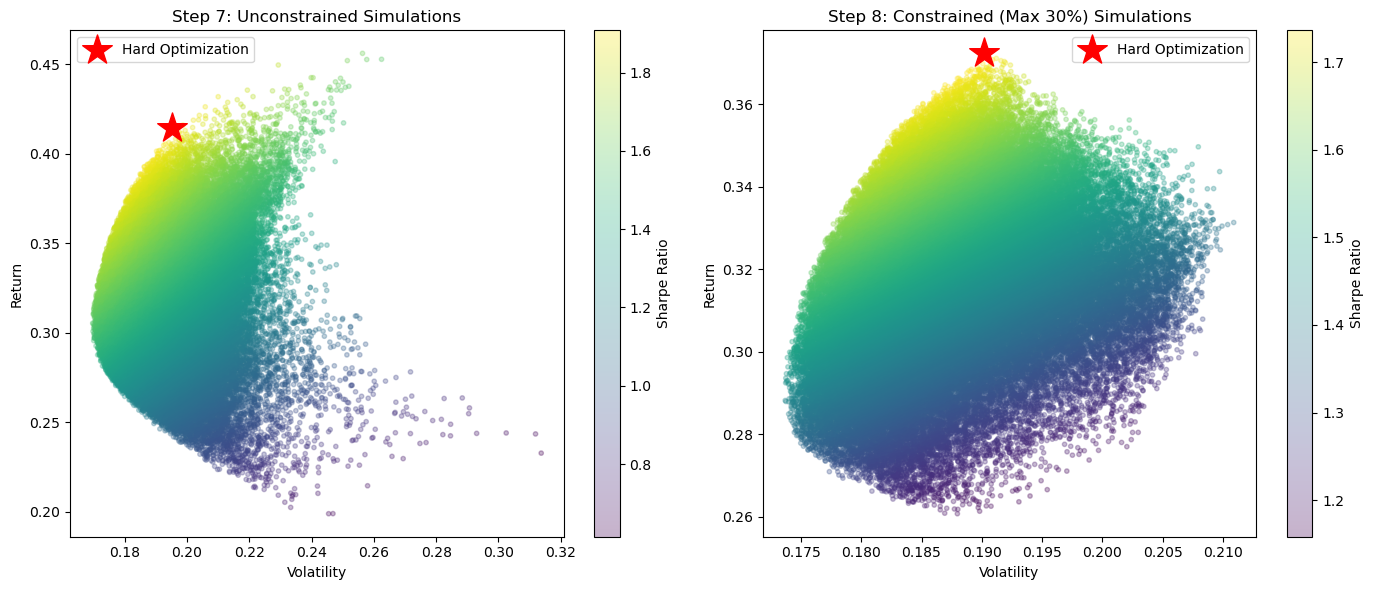

In [29]:
def run_simulations(num_portfolios, bounds_max=1.0):
    np.random.seed(42)
    results = np.zeros((3, num_portfolios))
    weights_record = []
    
    start_time = time.time()
    valid_count = 0
    total_attempts = 0
    
    # We use a while loop to ensure we get exactly 'num_portfolios' valid portfolios
    while valid_count < num_portfolios:
        total_attempts += 1
        weights = np.random.random(num_assets_5)
        weights /= np.sum(weights)
        
        # Check if weights violate the max bound constraint
        if np.any(weights > bounds_max):
            continue
            
        ret, vol, sharpe = portfolio_performance(weights, mean_returns_5, cov_matrix_5)
        results[0, valid_count] = ret
        results[1, valid_count] = vol
        results[2, valid_count] = sharpe
        weights_record.append(weights)
        valid_count += 1
        
    end_time = time.time()
    
    max_sharpe_idx = np.argmax(results[2])
    best_weights = weights_record[max_sharpe_idx]
    
    return results, best_weights, results[2, max_sharpe_idx], total_attempts, (end_time - start_time)

num_sims = 100000 # 100,000 simulations

print(f"\n--- STEP 7: SIMULATION ({num_sims:,} valid portfolios, No Max Weight) ---")
res_7, best_w_7, best_s_7, attempts_7, time_7 = run_simulations(num_sims, bounds_max=1.0)
print(f"Best Simulated Sharpe: {best_s_7:.4f} (Found in {attempts_7:,} attempts, took {time_7:.2f} seconds)")
for ticker, weight in zip(assets_5, best_w_7):
    print(f"{ticker}: {weight:.4f}")

print(f"\n--- STEP 8: SIMULATION ({num_sims:,} valid portfolios, Max 30% Weight) ---")
res_8, best_w_8, best_s_8, attempts_8, time_8 = run_simulations(num_sims, bounds_max=0.30)
print(f"Best Simulated Sharpe: {best_s_8:.4f} (Found in {attempts_8:,} attempts, took {time_8:.2f} seconds)")
for ticker, weight in zip(assets_5, best_w_8):
    print(f"{ticker}: {weight:.4f}")

# Plotting the Simulation Clouds vs Optimal Points
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(res_7[1,:], res_7[0,:], c=res_7[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(vol_opt_7, ret_opt_7, marker='*', color='r', s=500, label='Hard Optimization')
plt.title('Step 7: Unconstrained Simulations')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(res_8[1,:], res_8[0,:], c=res_8[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(vol_opt_8, ret_opt_8, marker='*', color='r', s=500, label='Hard Optimization')
plt.title('Step 8: Constrained (Max 30%) Simulations')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.legend()

plt.tight_layout()
plt.show()

# Part 4: The Black-Litterman Model

CONFIGURATION FOR PART 4 (Black-Litterman)

In [31]:
# Fetching Data for S&P 500 (SPY) for synthetic composite
tickers_11 = tickers + ['SPY']

# Fetch raw data first to handle yfinance column structure changes
data_11_raw = yf.download(tickers_11, start=train_start, end=train_end)

try:
    data_11 = data_11_raw['Adj Close']
except KeyError:
    try:
        data_11 = data_11_raw['Close']
    except KeyError:
        # Fallback for newer yfinance versions that might use lowercase
        data_11 = data_11_raw['close']

returns_11 = data_11.pct_change().dropna()

# 9(a) Synthetic Composite Approach
# To do this correctly, we need approximate market capitalizations to find the weights
# For simplicity and robust code execution, we will use fixed approximate market cap weights 
# for the 10 assets (in Trillions USD) as of late 2023/2024 to represent their relative size.
market_caps = {
    'AAPL': 3.0, 'WMT': 0.5, 'BAC': 0.3, 'GS': 0.15, 'LLY': 0.7, 
    'MRK': 0.3, 'GOOG': 2.0, 'META': 1.2, 'TSLA': 0.6, 'XOM': 0.4
}
total_10_cap = sum(market_caps.values())

# Assume total S&P 500 Market Cap is roughly $42 Trillion
sp500_total_cap = 42.0 
rest_of_sp_cap = sp500_total_cap - total_10_cap

# Calculate Market Weights for the 11 assets
mkt_weights = []
for t in tickers:
    mkt_weights.append(market_caps[t] / sp500_total_cap)
mkt_weights.append(rest_of_sp_cap / sp500_total_cap) # The 11th asset weight
w_mkt = np.array(mkt_weights)

print("\n--- Market Portfolio Weights ---")
for t, w in zip(tickers_11, w_mkt):
    print(f"{t}: {w:.4f}")

# Calculate Market Return, Volatility, and Sharpe
cov_matrix_11 = returns_11.cov() * trading_days
mkt_ret = np.sum(returns_11.mean() * trading_days * w_mkt)
mkt_vol = np.sqrt(np.dot(w_mkt.T, np.dot(cov_matrix_11, w_mkt)))
mkt_sharpe = (mkt_ret - risk_free_rate) / mkt_vol

print(f"\nMarket Portfolio Expected Return: {mkt_ret:.4f}")
print(f"Market Portfolio Volatility: {mkt_vol:.4f}")
print(f"Market Portfolio Sharpe Ratio: {mkt_sharpe:.4f}")

# Black-Litterman Parameters
# Risk Aversion Parameter (Lambda)
lam = (mkt_ret - risk_free_rate) / (mkt_vol ** 2)

# Implied Equilibrium Returns (Pi)
Pi = lam * np.dot(cov_matrix_11, w_mkt)

# 9(b) Choice of tau. Commonly set to 1/T, where T is the number of historical observations.
T = len(returns_11)
tau = 1.0 / T 
print(f"\nCalculated tau (1/T): {tau:.6f}")

# 9(c) Define Views (P) and Expected View Returns (Q)
# Let's define 2 views:
# View 1 (Absolute): TSLA will have an absolute return of 15% (0.15).
# View 2 (Relative): LLY will outperform MRK by 5% (0.05).
k = 2 # number of views
P = np.zeros((k, 11))
Q = np.zeros((k, 1))

# View 1: TSLA is index 0
P[0, 0] = 1.0
Q[0, 0] = 0.15

# View 2: LLY (index 4) > MRK (index 5) by 5%
P[1, 4] = 1.0
P[1, 5] = -1.0
Q[1, 0] = 0.05

# Uncertainty Matrix (Q_omega). Using the standard formula: Omega = tau * P * Sigma * P^T
Omega = np.zeros((k, k))
for i in range(k):
    p_i = P[i]
    Omega[i, i] = tau * np.dot(p_i, np.dot(cov_matrix_11, p_i.T))

print("\n--- View Matrix (P) ---")
print(P)
print("\n--- View Returns (Q) ---")
print(Q)

# 9(d) Calculate Black-Litterman Expected Returns (mu_BL) and Covariance (Sigma_BL)
tau_cov_inv = np.linalg.inv(tau * cov_matrix_11)
omega_inv = np.linalg.inv(Omega)

term1 = np.linalg.inv(tau_cov_inv + np.dot(P.T, np.dot(omega_inv, P)))
term2 = np.dot(tau_cov_inv, Pi) + np.dot(P.T, np.dot(omega_inv, Q.flatten()))
mu_BL = np.dot(term1, term2)

# Sigma_BL = Sigma + [(tau*Sigma)^-1 + P^T*Omega^-1*P]^-1
Sigma_BL = cov_matrix_11 + term1

print("\n--- Black-Litterman Expected Returns (mu_BL) ---")
for t, mu in zip(tickers_11, mu_BL):
    print(f"{t}: {mu:.4f}")

# Optimize Portfolio based on BL Returns (11 assets, constrained to max 18% for the original 10, rest of SPY max 100%)
def negative_sharpe_BL(weights, mean_returns, cov_matrix, risk_free_rate_val):
    returns = np.sum(mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -(returns - risk_free_rate_val) / std_dev

num_assets_11 = 11
args_BL = (mu_BL, Sigma_BL, risk_free_rate)
cons_BL = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds_BL = tuple((0.0, 0.18) if i < 10 else (0.0, 1.0) for i in range(num_assets_11))

res_BL = sco.minimize(negative_sharpe_BL, num_assets_11*[1./num_assets_11,], args=args_BL,
                      method='SLSQP', bounds=bounds_BL, constraints=cons_BL)

weights_BL = res_BL.x

print("\n--- 9(e) Optimal Black-Litterman Portfolio Weights ---")
for t, w in zip(tickers_11, weights_BL):
    print(f"{t}: {w:.4f}")

[*********************100%***********************]  11 of 11 completed



--- Market Portfolio Weights ---
TSLA: 0.0143
WMT: 0.0119
BAC: 0.0071
GS: 0.0036
LLY: 0.0167
MRK: 0.0071
GOOG: 0.0476
META: 0.0286
AAPL: 0.0714
XOM: 0.0095
SPY: 0.7821

Market Portfolio Expected Return: 0.1020
Market Portfolio Volatility: 0.1920
Market Portfolio Sharpe Ratio: 0.3230

Calculated tau (1/T): 0.001923

--- View Matrix (P) ---
[[ 1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  1. -1.  0.  0.  0.  0.  0.]]

--- View Returns (Q) ---
[[0.15]
 [0.05]]

--- Black-Litterman Expected Returns (mu_BL) ---
TSLA: 0.0882
WMT: 0.0564
BAC: 0.0406
GS: 0.0655
LLY: 0.0493
MRK: 0.0377
GOOG: 0.0290
META: 0.0478
AAPL: 0.1279
XOM: 0.0254
SPY: 0.0774

--- 9(e) Optimal Black-Litterman Portfolio Weights ---
TSLA: 0.1800
WMT: 0.0000
BAC: 0.0000
GS: 0.0000
LLY: 0.0034
MRK: 0.0000
GOOG: 0.0000
META: 0.0000
AAPL: 0.1520
XOM: 0.0000
SPY: 0.6645
